# Case Duration Prediction — standalone validation

Does `train_case_duration_pipeline` / `predict_case_duration` (sim_extractor.py) actually predict a case's total duration better than a trivial "always guess the training median" baseline? This is evaluated **independently** of the downstream duration-corrected curve reconstruction ("Best, duration-corrected") -- here we only check the regressor's own accuracy on held-out real cases, per process.

Trains live on the real gold data (`data/gold/experiment_1/<process>/datasets/df_expanded.parquet`), with an independent random 80/20 train/test split per process (not necessarily the same split used by the production pipeline -- this is a standalone sanity check).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

import sim_extractor as se
import importlib
importlib.reload(se)

GOLD_DIR = '/home/david/repos/process_energy_demand_modelling/data/gold/experiment_1'
PROCESSES = ['process_1', 'process_2', 'process_3', 'process_4_1', 'process_4_2', 'process_5']
TEST_SIZE = 0.2
RANDOM_STATE = 42


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



### Train + evaluate per process

For each process: pick the sensor with the widest case coverage (so we lose as few cases as possible to `build_case_level_curves`' per-sensor filtering), split cases into train/test, train the duration pipeline on train, and compare its held-out test predictions against (a) the real durations and (b) a trivial "predict the train-set median duration for every case" baseline -- the exact floor `use_median_fallback` is designed to fall back to when the model doesn't actually beat it.

In [2]:
def _detect_sensors(df):
    return [c for c in df.columns if c.endswith('_energy_to_model')]

def _detect_ef_cols(df):
    return [c for c in df.columns if c.startswith('ef_') and pd.api.types.is_numeric_dtype(df[c])]

results_rows = []
per_process = {}

for proc in PROCESSES:
    path = f'{GOLD_DIR}/{proc}/datasets/df_expanded.parquet'
    if not os.path.exists(path):
        print(f'{proc}: no data at {path}, skipping')
        continue
    df = pd.read_parquet(path)
    sensors = _detect_sensors(df)
    ef_cols = _detect_ef_cols(df)
    if not sensors:
        print(f'{proc}: no sensors detected, skipping')
        continue

    # Pick the sensor with the most case coverage, so we build the widest case set --
    # duration_minutes/attributes are the same regardless of which sensor's curve was
    # used to build them (case duration doesn't depend on sensor), only case COVERAGE does.
    best_sensor, best_cases = None, []
    for s in sensors:
        cases = se.build_case_level_curves(df, s, ef_cols=ef_cols)
        if len(cases) > len(best_cases):
            best_sensor, best_cases = s, cases
    cases = best_cases
    print(f'{proc}: {len(cases)} cases built (widest sensor={best_sensor}, '
          f'{len(sensors)} sensors total, {len(ef_cols)} ef_cols)')
    if len(cases) < 8:
        print(f'  too few cases ({len(cases)}) -- skipping')
        continue

    train_idx, test_idx = train_test_split(
        range(len(cases)), test_size=TEST_SIZE, random_state=RANDOM_STATE)
    train_cases = [cases[i] for i in train_idx]
    test_cases  = [cases[i] for i in test_idx]

    pipeline = se.train_case_duration_pipeline(train_cases, random_state=RANDOM_STATE, verbose=1)
    if pipeline is None:
        print(f'  {proc}: could not train (too few train cases) -- skipping')
        continue

    train_median = float(np.median([c['duration_minutes'] for c in train_cases]))
    y_true        = np.array([c['duration_minutes'] for c in test_cases])
    y_pred_model  = np.array([se.predict_case_duration(c['attributes'], pipeline) for c in test_cases])
    y_pred_median = np.full_like(y_true, train_median)

    mae_model    = mean_absolute_error(y_true, y_pred_model)
    mae_median   = mean_absolute_error(y_true, y_pred_median)
    rmse_model   = float(np.sqrt(mean_squared_error(y_true, y_pred_model)))
    rmse_median  = float(np.sqrt(mean_squared_error(y_true, y_pred_median)))
    mape_model   = float(np.mean(np.abs(y_pred_model  - y_true) / y_true)) * 100
    mape_median  = float(np.mean(np.abs(y_pred_median - y_true) / y_true)) * 100

    results_rows.append({
        'process': proc,
        'n_train': len(train_cases), 'n_test': len(test_cases),
        'used_median_fallback (internal, val)': pipeline.get('use_median_fallback', False),
        'val MAE (internal)':          pipeline.get('val_mae'),
        'val baseline MAE (internal)': pipeline.get('baseline_val_mae'),
        'Model MAE (test, min)':            mae_model,
        'Median-baseline MAE (test, min)':  mae_median,
        'Model RMSE (test, min)':           rmse_model,
        'Median-baseline RMSE (test, min)': rmse_median,
        'Model MAPE (test, %)':             mape_model,
        'Median-baseline MAPE (test, %)':   mape_median,
        'Model beats median baseline (test)': bool(mae_model < mae_median),
    })
    per_process[proc] = {
        'y_true': y_true, 'y_pred_model': y_pred_model, 'y_pred_median': y_pred_median,
        'sensor': best_sensor,
    }

summary = pd.DataFrame(results_rows).set_index('process')
display(summary.round(2))


process_1: 300 cases built (widest sensor=destillation_steam_demand_kW_energy_to_model, 7 sensors total, 2 ef_cols)
  [case-duration] trained on 240 cases, val_mae=31.35 min vs. median baseline=28.53 min -> using median fallback (model did not beat it)


process_2: 48 cases built (widest sensor=pro_menge_kg_energy_to_model, 5 sensors total, 3 ef_cols)
  [case-duration] trained on 38 cases, val_mae=221.09 min vs. median baseline=334.50 min -> using model


process_3: 49 cases built (widest sensor=pro_menge_kg_energy_to_model, 5 sensors total, 3 ef_cols)
  [case-duration] trained on 39 cases, val_mae=80.97 min vs. median baseline=383.54 min -> using model


process_4_1: 160 cases built (widest sensor=(10)_abluft_temp_c_energy_to_model, 23 sensors total, 2 ef_cols)
  [case-duration] trained on 128 cases, val_mae=57.47 min vs. median baseline=183.77 min -> using model


process_4_2: 156 cases built (widest sensor=(10)_abluft_temp_c_energy_to_model, 23 sensors total, 2 ef_cols)
  [case-duration] trained on 124 cases, val_mae=38.79 min vs. median baseline=218.16 min -> using model


process_5: 53 cases built (widest sensor=temp_Auslauf_EG_(WT2)_5s_energy_to_model, 28 sensors total, 3 ef_cols)
  [case-duration] trained on 42 cases, val_mae=40.83 min vs. median baseline=258.30 min -> using model


,n_train,n_test,"used_median_fallback (internal, val)",val MAE (internal),val baseline MAE (internal),"Model MAE (test, min)","Median-baseline MAE (test, min)","Model RMSE (test, min)","Median-baseline RMSE (test, min)","Model MAPE (test, %)","Median-baseline MAPE (test, %)",Model beats median baseline (test)
process,,,,,,,,,,,,
process_1,240,60,True,31.35,28.53,26.07,26.11,36.06,35.94,19.16,19.27,True
process_2,38,10,False,221.09,334.50,272.53,245.28,312.06,384.92,85.57,55.20,False
process_3,39,10,False,80.97,383.54,455.45,556.87,946.35,1017.83,47.23,57.58,True
process_4_1,128,32,False,57.47,183.77,43.93,289.69,60.87,405.94,4.69,50.00,True
process_4_2,124,32,False,38.79,218.16,54.04,393.25,74.36,588.55,9.35,273.18,True
process_5,42,11,False,40.83,258.30,63.44,233.23,86.88,298.47,17.89,107.07,True


### Scatter: predicted vs. real duration, per process

Points on the black dashed diagonal = perfect prediction. Gray X's show where the trivial median baseline sits for each real duration (a horizontal-ish scatter at the train median, by construction). If the blue model points hug the diagonal noticeably tighter than the gray X's, the regressor is adding real signal beyond the median-baseline it's meant to beat.

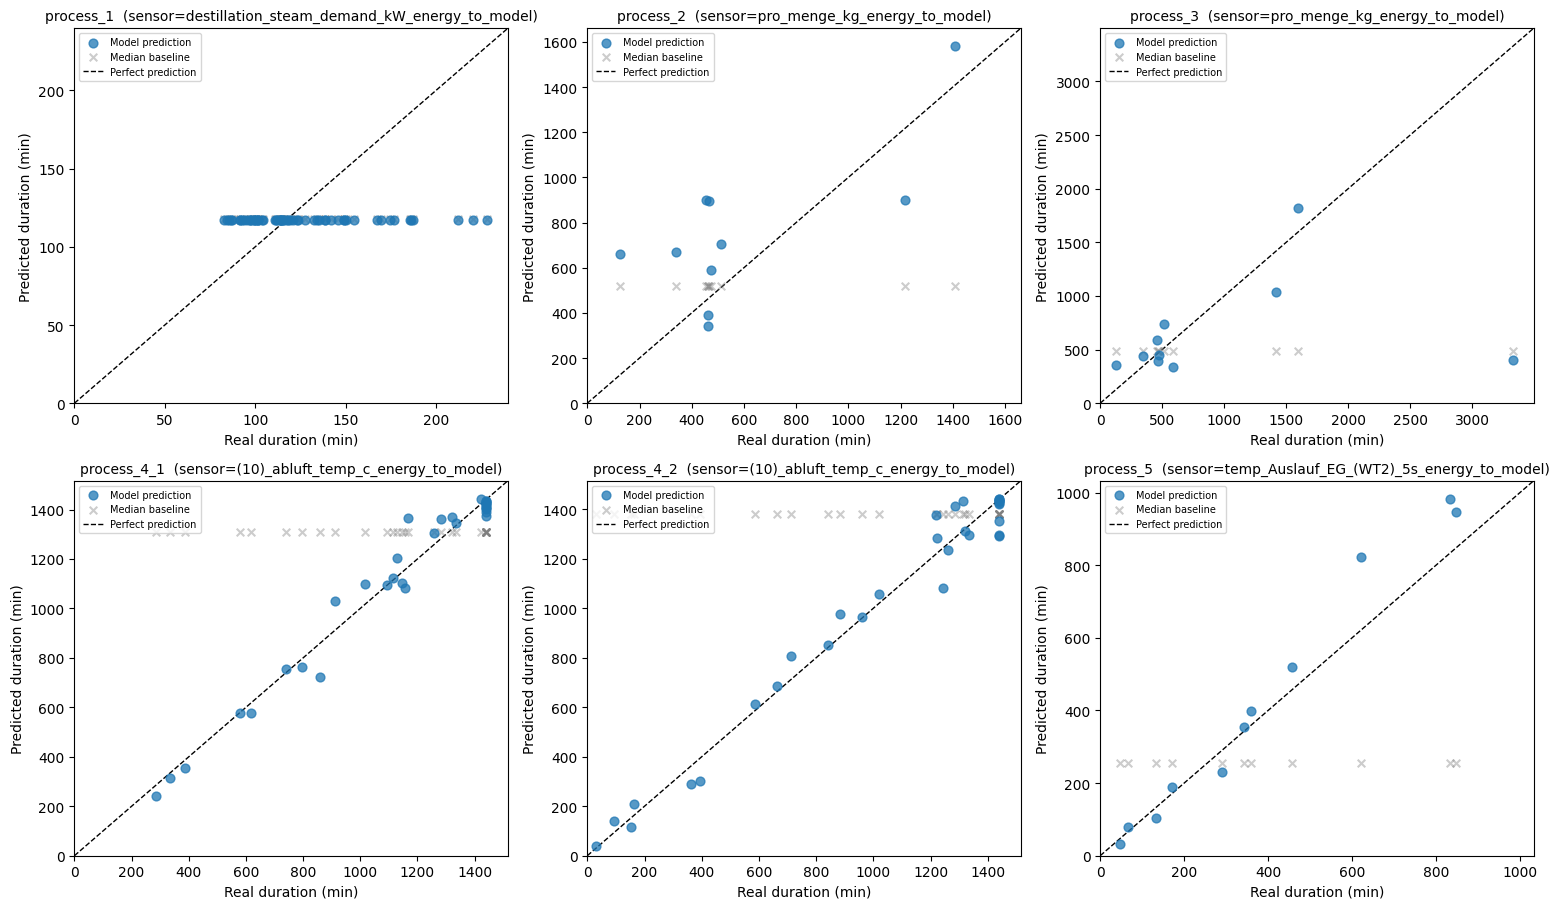

In [3]:
n = len(per_process)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.2*ncols, 4.6*nrows), squeeze=False)

for i, (proc, d) in enumerate(per_process.items()):
    ax = axes[i // ncols][i % ncols]
    y_true, y_pred, y_med = d['y_true'], d['y_pred_model'], d['y_pred_median']
    ax.scatter(y_true, y_pred, alpha=0.75, s=40, label='Model prediction', zorder=3)
    ax.scatter(y_true, y_med, alpha=0.4, s=30, marker='x', color='gray', label='Median baseline', zorder=2)
    lims = [0, max(y_true.max(), y_pred.max(), y_med.max()) * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=1, label='Perfect prediction', zorder=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Real duration (min)')
    ax.set_ylabel('Predicted duration (min)')
    ax.set_title(f'{proc}  (sensor={d["sensor"]})', fontsize=10)
    ax.legend(fontsize=7, loc='upper left')

for j in range(len(per_process), nrows * ncols):
    axes[j // ncols][j % ncols].axis('off')

plt.tight_layout()
plt.show()
